# Stage 5 -- Three-way comparison: PCA, Noam, Bayesian

This notebook compares the three methods on the 6 primary blocks x 2 hands.
It uses the fixed Bayesian phase-0 anchoring from
`bayes_tau_delta_funnel_diagnostic.ipynb`; `04_bayesian.ipynb` remains a
historical record of the earlier anchoring implementation.

There are two deliberately separate comparisons below:

1. **Observed cycles, apples to apples.** Each method supplies only its cycle
   boundaries. The same raw hand-Y-relative-to-root samples are sliced and
   normalized between those boundaries. No reconstructed PCA trajectory or
   Bayesian posterior fitted trajectory enters this comparison.
2. **Boundary placement.** Bayesian and Noam boundaries are expressed in the
   PCA phase coordinate. This shows directly whether a discrepancy is one
   common phase shift or changes by condition.

The PCA boundaries are phase-anchored to Noam's peak/trough convention via
`phase_reference`. The Bayesian model instead defines phase zero through its
own boundary criterion, which favors spatially compact cross-cycle boundaries
(`rho_tau`). The plots below show the empirical consequence rather than
assuming the two conventions coincide.

In [1]:
import sys, pickle
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.signal import savgol_filter, find_peaks

sys.path.insert(0, str(Path.cwd()))
import _loading as L
import _plotting as P

with open("cache/pca_results.pkl", "rb") as f:
    PCA_CACHE = pickle.load(f)
with open("cache/bayes_results_both_hands.pkl", "rb") as f:
    BAYES_CACHE = pickle.load(f)

RUNS_DF = L.list_available_blocks(subject="002")
print("PCA fits:", len(PCA_CACHE), " | Bayesian fits:", len(BAYES_CACHE), " | runs table rows:", len(RUNS_DF))

FS_HZ = 60.0
CYCLE_PARAMS = {
    "sampling_frequency_hz": FS_HZ,
    "detection": {
        "walk": {"event_type_by_hand": {"r_hand": "peaks", "l_hand": "troughs"}, "smooth_window": 9, "smooth_polyorder": 3,
                 "prominence_sd_factor": 0.10, "min_event_distance_sec": 0.20, "min_cycle_duration_sec": 0.50,
                 "max_cycle_duration_sec": 3.10, "min_cycle_amplitude": 10},
        "jump": {"event_type_by_hand": {"r_hand": "peaks", "l_hand": "peaks"}, "smooth_window": 9, "smooth_polyorder": 3,
                 "prominence_sd_factor": 0.10, "min_event_distance_sec": 0.20, "min_cycle_duration_sec": 0.40,
                 "max_cycle_duration_sec": 1.50, "min_cycle_amplitude": None},
        "climb": {"event_type_by_hand": {"r_hand": "peaks", "l_hand": "peaks"}, "smooth_window": 9, "smooth_polyorder": 3,
                  "prominence_sd_factor": 0.10, "min_event_distance_sec": 0.20, "min_cycle_duration_sec": 0.40,
                  "max_cycle_duration_sec": 1.70, "min_cycle_amplitude": None},
    },
}

METHOD_COLORS = {"Noam": "#e76f51", "PCA": "#0096c7", "Bayesian": "#4d4d4d"}
TRACE_HAND_COLORS = {"r_hand": "#3b7ddd", "l_hand": "#7a5195"}


def smooth_signal(values, window_length, polyorder):
    values = np.asarray(values, dtype=float)
    if len(values) < 5:
        return values.copy()
    window_length = int(window_length) + (int(window_length) % 2 == 0)
    maximum = len(values) if len(values) % 2 else len(values) - 1
    window_length = min(window_length, maximum)
    if window_length <= polyorder or window_length < 5:
        return values.copy()
    return savgol_filter(values, window_length, polyorder)


def noam_detection_indices(raw, skill, hand, parameters):
    config = parameters["detection"][skill]
    smooth = smooth_signal(raw, config["smooth_window"], config["smooth_polyorder"])
    event_type = config["event_type_by_hand"][hand]
    prominence = config["prominence_sd_factor"] * np.nanstd(smooth)
    distance = max(1, round(config["min_event_distance_sec"] * parameters["sampling_frequency_hz"]))
    events, _ = find_peaks(smooth if event_type == "peaks" else -smooth,
                           distance=distance, prominence=prominence)
    return smooth, np.asarray(events, dtype=int)


def extract_noam_cycles(raw, skill, hand, parameters):
    """Return accepted Noam windows; waveform samples are extracted later."""
    config = parameters["detection"][skill]
    fps = parameters["sampling_frequency_hz"]
    smooth, events = noam_detection_indices(raw, skill, hand, parameters)
    cycles = []
    for start, end in zip(events[:-1], events[1:]):
        duration = (end - start) / fps
        if duration < config["min_cycle_duration_sec"] or duration > config["max_cycle_duration_sec"]:
            continue
        smooth_cycle = smooth[start:end + 1]
        if not np.isfinite(smooth_cycle).all():
            continue
        amplitude = float(np.ptp(smooth_cycle))
        if config["min_cycle_amplitude"] is not None and amplitude < config["min_cycle_amplitude"]:
            continue
        cycles.append({"start": int(start), "stop": int(end),
                       "duration_sec": float(duration), "amplitude": amplitude})
    return cycles


def raw_signal_for_run(subject, day, part, skill, run_id, hand):
    match = RUNS_DF[(RUNS_DF.subject == subject) & (RUNS_DF.day == day) & (RUNS_DF.part == part)
                    & (RUNS_DF.skill == skill) & (RUNS_DF.movement_run_id == run_id)]
    row = match.iloc[0]
    frame = L.load_position_file(row["path"]).iloc[int(row["run_start"]):int(row["run_end"])]
    return (pd.to_numeric(frame[f"{hand}.y"]) - pd.to_numeric(frame["root.y"])).to_numpy(dtype=float)


def phase_reference(skill, hand):
    event_type = CYCLE_PARAMS["detection"][skill]["event_type_by_hand"][hand]
    return 0.0 if event_type == "peaks" else np.pi


def phase_detection_indices(phase_unwrapped, reference):
    shifted = np.asarray(phase_unwrapped, dtype=float) - reference
    cycle = np.floor(shifted / (2 * np.pi)).astype(int)
    return np.flatnonzero(np.diff(cycle) != 0) + 1


def windows_from_boundaries(boundaries, min_samples=2):
    boundaries = np.asarray(boundaries, dtype=int)
    return [(int(start), int(stop)) for start, stop in zip(boundaries[:-1], boundaries[1:])
            if stop - start >= min_samples]


def normalized_raw_cycles(raw, windows, n_points=100):
    """Resample the same observed signal within method-specific [start, stop) windows."""
    result = []
    for start, stop in windows:
        start, stop = max(0, int(start)), min(len(raw), int(stop))
        segment = np.asarray(raw[start:stop], dtype=float)
        if len(segment) < 2 or not np.isfinite(segment).all():
            continue
        result.append(np.interp(np.linspace(0, 1, n_points),
                                np.linspace(0, 1, len(segment)), segment))
    return result


def bayesian_boundary_indices(cycles):
    if cycles.empty:
        return np.array([], dtype=int)
    return np.unique(np.r_[cycles["sample_start"].to_numpy(dtype=int),
                           cycles["sample_stop"].to_numpy(dtype=int)])


def phase_position_pct(phase, indices, reference):
    """Boundary position in the PCA cycle, wrapped to [-50, 50) percent."""
    indices = np.asarray(indices, dtype=int)
    indices = indices[(indices >= 0) & (indices < len(phase))]
    angle = (np.asarray(phase)[indices] - reference + np.pi) % (2 * np.pi) - np.pi
    return angle / (2 * np.pi) * 100


def circular_center_pct(values):
    angles = np.asarray(values, dtype=float) / 100 * 2 * np.pi
    return np.arctan2(np.mean(np.sin(angles)), np.mean(np.cos(angles))) / (2 * np.pi) * 100


primary_rows = (RUNS_DF.sort_values("run_duration_sec", ascending=False)
                .groupby(["day", "part", "skill"], as_index=False).first())
print("6 primary blocks:")
print(primary_rows[["day", "part", "skill", "source_file", "movement_run_id", "run_duration_sec"]].to_string(index=False))

Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\User\\.matplotlib\\fontlist-v3.11.0.json.matplotlib-lock'


Detected hostname: DESKTOP-P681IHN
Using root directory: D:\Repositories\phase-coordinates\test_data
Detected hostname: DESKTOP-P681IHN
Using root directory: D:\Repositories\phase-coordinates\test_data


PCA fits: 116  | Bayesian fits: 12  | runs table rows: 58
6 primary blocks:
 day part skill source_file  movement_run_id  run_duration_sec
   1    s climb   002-1-s-c                6         22.983333
   1    s  jump   002-1-s-j                1          8.983333
   1    s  walk   002-1-s-w                1         25.983333
   3    e climb   002-3-e-c                5         28.983333
   3    e  jump   002-3-e-j                5         30.983333
   3    e  walk   002-3-e-w                9         14.983333


## Cycle count, duration, and observed cycle shape

This is the apples-to-apples waveform comparison. All three methods slice the
**same observed hand-Y-relative-to-root signal**. The only method-dependent
quantity is the set of cycle boundaries. Thin ribbons show the interquartile
range of observed cycles and thick lines show their mean. Consequently,
differences in a Bayesian fitted trajectory cannot create differences here.

In [2]:
comparison_rows = []
cycle_shapes = {}
boundary_phase_rows = []
boundary_gap_rows = []

for _, prow in primary_rows.iterrows():
    day, part, skill = prow.day, prow.part, prow.skill
    run_id, source_file = prow.movement_run_id, prow.source_file
    for hand in ["r_hand", "l_hand"]:
        pca_key = ("002", day, part, skill, source_file, run_id, hand)
        bayes_key = ("002", day, part, skill, hand)
        if pca_key not in PCA_CACHE or bayes_key not in BAYES_CACHE:
            continue

        pca_entry, bayes_entry = PCA_CACHE[pca_key], BAYES_CACHE[bayes_key]
        raw = raw_signal_for_run("002", day, part, skill, run_id, hand)
        phase = pca_entry["samples"]["phase"].to_numpy(dtype=float)
        ref = phase_reference(skill, hand)

        pca_boundaries = phase_detection_indices(phase, ref)
        pca_windows = windows_from_boundaries(pca_boundaries, min_samples=5)
        noam_cycles = extract_noam_cycles(raw, skill, hand, CYCLE_PARAMS)
        noam_windows = [(cycle["start"], cycle["stop"]) for cycle in noam_cycles]
        _, noam_boundaries = noam_detection_indices(raw, skill, hand, CYCLE_PARAMS)
        bayes_cycles = bayes_entry["cycles"]
        bayes_windows = [(int(row.sample_start), int(row.sample_stop))
                         for _, row in bayes_cycles.iterrows()]
        bayes_boundaries = bayesian_boundary_indices(bayes_cycles)

        method_windows = {"Noam": noam_windows, "PCA": pca_windows, "Bayesian": bayes_windows}
        stats = {}
        for method, windows in method_windows.items():
            cycles = normalized_raw_cycles(raw, windows)
            if cycles:
                stack = np.vstack(cycles)
                stats[method] = {
                    "mean": np.mean(stack, axis=0),
                    "q25": np.quantile(stack, 0.25, axis=0),
                    "q75": np.quantile(stack, 0.75, axis=0),
                    "n": len(cycles),
                }
            else:
                stats[method] = None
        cycle_shapes[(day, part, skill, hand)] = stats

        comparison_rows.append({
            "day": day, "part": part, "skill": skill, "hand": hand,
            "n_cycles_pca": len(pca_windows), "n_cycles_noam": len(noam_windows),
            "n_cycles_bayes": len(bayes_windows),
            "median_duration_pca": np.median([(stop - start) / FS_HZ for start, stop in pca_windows]),
            "median_duration_noam": np.median([cycle["duration_sec"] for cycle in noam_cycles]),
            "median_duration_bayes": float(bayes_cycles["duration"].median()),
        })

        # Locate each alternative boundary in the PCA cycle. PCA itself is zero by construction.
        for method, indices in [("Noam", noam_boundaries), ("Bayesian", bayes_boundaries)]:
            positions = phase_position_pct(phase, indices, ref)
            valid_indices = indices[(indices >= 0) & (indices < len(phase))]
            for idx, position in zip(valid_indices, positions):
                boundary_phase_rows.append({
                    "day": day, "part": part, "skill": skill, "hand": hand,
                    "method": method, "event_idx": int(idx),
                    "phase_position_pct": float(position),
                })

        # Match each interior Bayesian boundary to the nearest PCA boundary for detailed views.
        if len(pca_boundaries):
            interior = bayes_boundaries[(bayes_boundaries >= pca_boundaries[0])
                                        & (bayes_boundaries <= pca_boundaries[-1])]
            for bayes_idx in interior:
                pca_idx = int(pca_boundaries[np.argmin(np.abs(pca_boundaries - bayes_idx))])
                boundary_gap_rows.append({
                    "day": day, "part": part, "skill": skill, "hand": hand,
                    "source_file": source_file, "run_id": run_id,
                    "bayes_event_idx": int(bayes_idx), "pca_event_idx": pca_idx,
                    "signed_gap_sec": float((bayes_idx - pca_idx) / FS_HZ),
                    "gap_sec": float(abs(bayes_idx - pca_idx) / FS_HZ),
                })

comparison_df = pd.DataFrame(comparison_rows)
boundary_phase_df = pd.DataFrame(boundary_phase_rows)
boundary_gaps_df = pd.DataFrame(boundary_gap_rows)
comparison_df

,day,part,skill,hand,n_cycles_pca,n_cycles_noam,n_cycles_bayes,median_duration_pca,median_duration_noam,median_duration_bayes
0,1,s,climb,r_hand,19,18,20,1.050000,1.066667,1.063995
1,1,s,climb,l_hand,20,18,18,1.133333,1.066667,1.111914
2,1,s,jump,r_hand,9,8,9,0.950000,0.925000,0.933171
3,1,s,jump,l_hand,8,9,7,1.008333,0.916667,0.978866
4,1,s,walk,r_hand,24,24,24,1.033333,1.033333,1.045502
5,1,s,walk,l_hand,24,24,25,1.025000,1.033333,1.034039
6,3,e,climb,r_hand,37,37,37,0.750000,0.750000,0.750737
7,3,e,climb,l_hand,37,38,38,0.750000,0.750000,0.750734
8,3,e,jump,r_hand,40,40,40,0.750000,0.750000,0.748141
9,3,e,jump,l_hand,40,40,40,0.750000,0.758333,0.748437


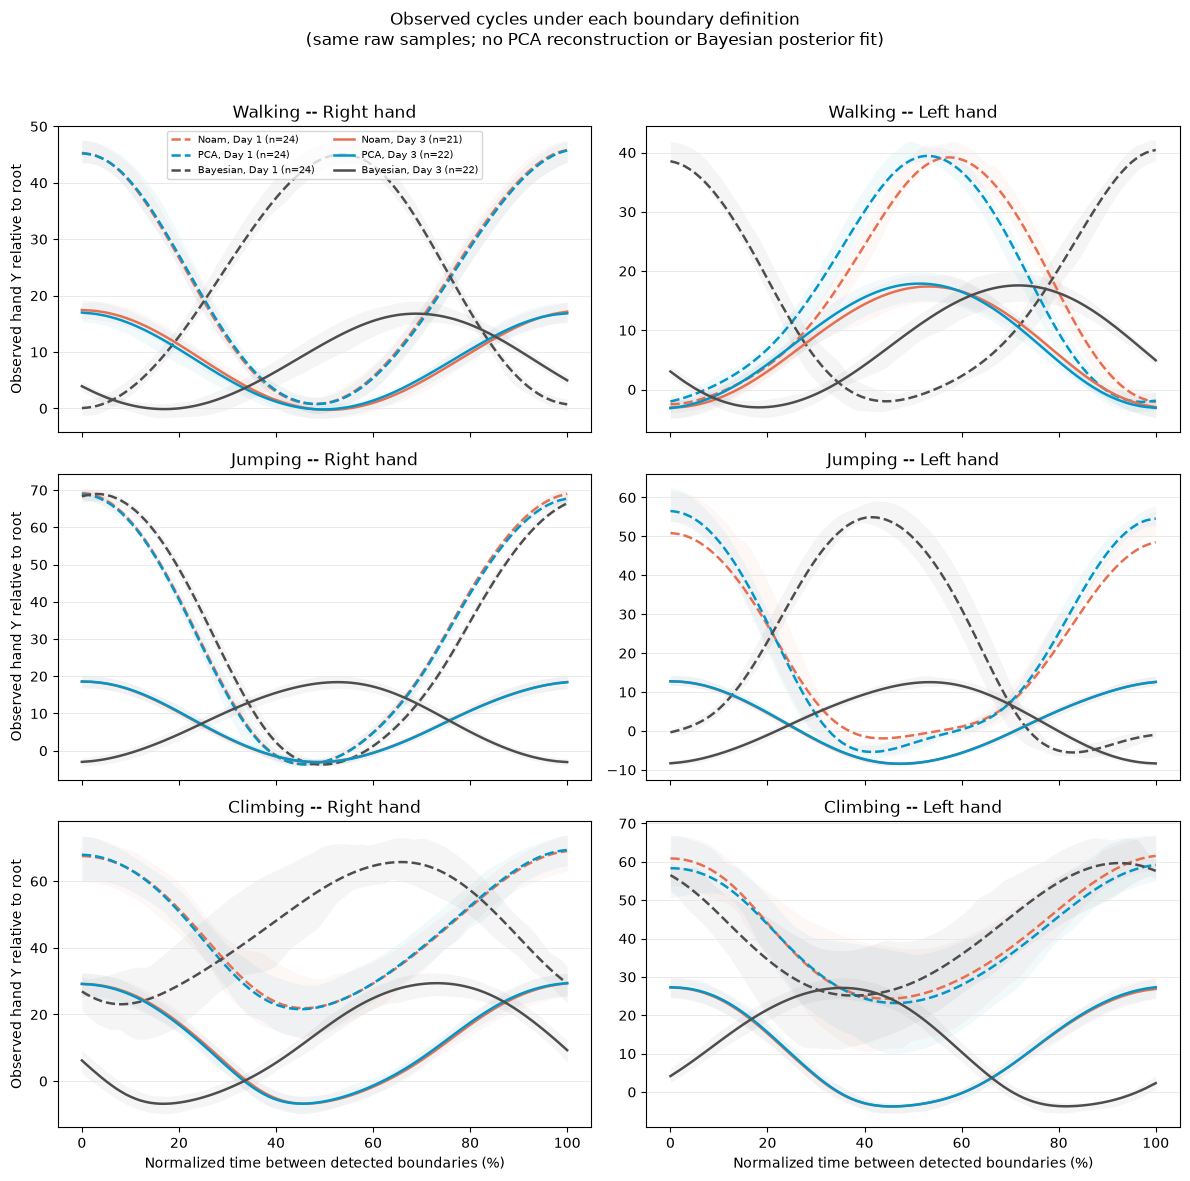

In [3]:
fig, axes = plt.subplots(3, 2, figsize=(12, 12), sharex=True)
t = np.linspace(0, 100, 100)
for row_idx, skill in enumerate(["walk", "jump", "climb"]):
    for col_idx, hand in enumerate(["r_hand", "l_hand"]):
        ax = axes[row_idx, col_idx]
        for (day, part, sk, hd), method_stats in cycle_shapes.items():
            if sk != skill or hd != hand:
                continue
            for method in ["Noam", "PCA", "Bayesian"]:
                stats = method_stats[method]
                if stats is None:
                    continue
                color = METHOD_COLORS[method]
                linestyle = P.DAY_LINESTYLES[day]
                ax.fill_between(t, stats["q25"], stats["q75"], color=color, alpha=0.055, linewidth=0)
                ax.plot(t, stats["mean"], color=color, linestyle=linestyle, linewidth=1.8,
                        label=f"{method}, Day {day} (n={stats['n']})")
        ax.set_title(f"{P.SKILL_LABELS[skill]} -- {P.HAND_LABELS[hand]}")
        ax.grid(axis="y", color="0.9", linewidth=0.6)
        if row_idx == 0 and col_idx == 0:
            ax.legend(fontsize=7, ncol=2)

for ax in axes[-1, :]:
    ax.set_xlabel("Normalized time between detected boundaries (%)")
for ax in axes[:, 0]:
    ax.set_ylabel("Observed hand Y relative to root")
fig.suptitle("Observed cycles under each boundary definition\n(same raw samples; no PCA reconstruction or Bayesian posterior fit)")
fig.tight_layout(rect=(0, 0, 1, 0.96))
P.save_figure(fig, "stage5_three_way_mean_cycle_shape")
plt.show()

## Where does each method put phase zero?

Each point below is a detected boundary evaluated in the PCA phase coordinate.
The blue horizontal line is therefore PCA phase zero. Noam should remain near
that line because PCA was explicitly anchored to Noam's peak/trough convention.

The key diagnostic is the Bayesian position across the 12 condition-hand
combinations. If Bayesian differed from PCA by one global phase offset, its
points and black circular-center markers would occupy approximately one common
horizontal level. Different levels indicate condition-specific phase origins.
Values wrap at +/-50% of a cycle, so +50% and -50% are adjacent.

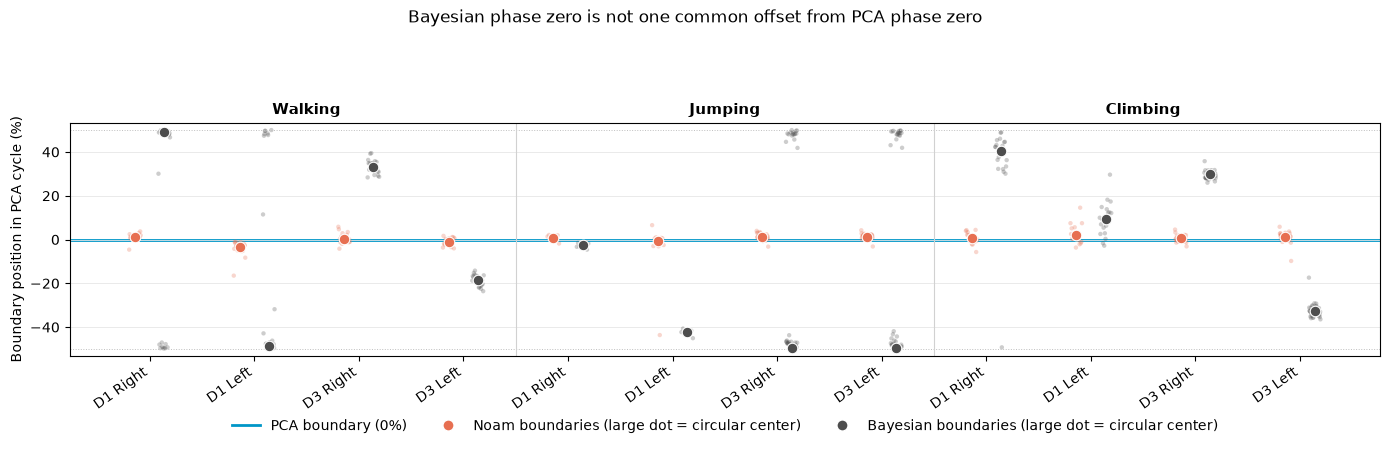

In [4]:
condition_order = [
    (day, skill, hand)
    for skill in ["walk", "jump", "climb"]
    for day in [1, 3]
    for hand in ["r_hand", "l_hand"]
]

fig, ax = plt.subplots(figsize=(14, 5.5))
method_x_offset = {"Noam": -0.14, "Bayesian": 0.14}
for x, (day, skill, hand) in enumerate(condition_order):
    subset = boundary_phase_df[(boundary_phase_df.day == day)
                               & (boundary_phase_df.skill == skill)
                               & (boundary_phase_df.hand == hand)]
    for method in ["Noam", "Bayesian"]:
        values = subset.loc[subset.method == method, "phase_position_pct"].to_numpy()
        if not len(values):
            continue
        jitter = np.linspace(-0.055, 0.055, len(values)) if len(values) > 1 else np.array([0.0])
        xpos = x + method_x_offset[method]
        ax.scatter(xpos + jitter, values, s=10, color=METHOD_COLORS[method], alpha=0.28,
                   edgecolors="none", zorder=2)
        center = circular_center_pct(values)
        ax.scatter(xpos, center, s=58, color=METHOD_COLORS[method], edgecolor="white",
                   linewidth=0.8, zorder=4)

ax.axhline(0, color=METHOD_COLORS["PCA"], linewidth=2.0, label="PCA boundary (0%)", zorder=1)
ax.axhline(50, color="0.75", linewidth=0.7, linestyle=":")
ax.axhline(-50, color="0.75", linewidth=0.7, linestyle=":")
for separator in [3.5, 7.5]:
    ax.axvline(separator, color="0.82", linewidth=0.8)
ax.set_xticks(range(len(condition_order)))
ax.set_xticklabels([f"D{day} {P.HAND_LABELS[hand].replace(' hand', '')}"
                    for day, _, hand in condition_order], rotation=35, ha="right")
for start, skill in zip([0, 4, 8], ["walk", "jump", "climb"]):
    ax.text(start + 1.5, 1.025, P.SKILL_LABELS[skill], transform=ax.get_xaxis_transform(),
            ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylim(-53, 53)
ax.set_ylabel("Boundary position in PCA cycle (%)")
ax.grid(axis="y", color="0.9", linewidth=0.6)
ax.legend(handles=[
    Line2D([0], [0], color=METHOD_COLORS["PCA"], lw=2, label="PCA boundary (0%)"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor=METHOD_COLORS["Noam"],
           markeredgecolor="white", markersize=8, label="Noam boundaries (large dot = circular center)"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor=METHOD_COLORS["Bayesian"],
           markeredgecolor="white", markersize=8, label="Bayesian boundaries (large dot = circular center)"),
], loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.22))
fig.suptitle("Bayesian phase zero is not one common offset from PCA phase zero", y=0.985)
fig.tight_layout(rect=(0, 0.10, 1, 0.91))
P.save_figure(fig, "stage5_boundary_position_in_pca_cycle")
plt.show()

### Largest Bayesian--PCA boundary gaps: three-cycle views

This reuses the three-cycle format from `02_compare_noam.ipynb`. For each
skill and day/block, the three largest absolute Bayesian-to-nearest-PCA gaps
are selected. The selected Bayesian boundary is time zero; its nearest PCA
boundary is highlighted, and the interval between them is shaded on the
triggering hand. Noam detections are marked in coral for an independent
waveform-based reference. Both hands are shown for context.

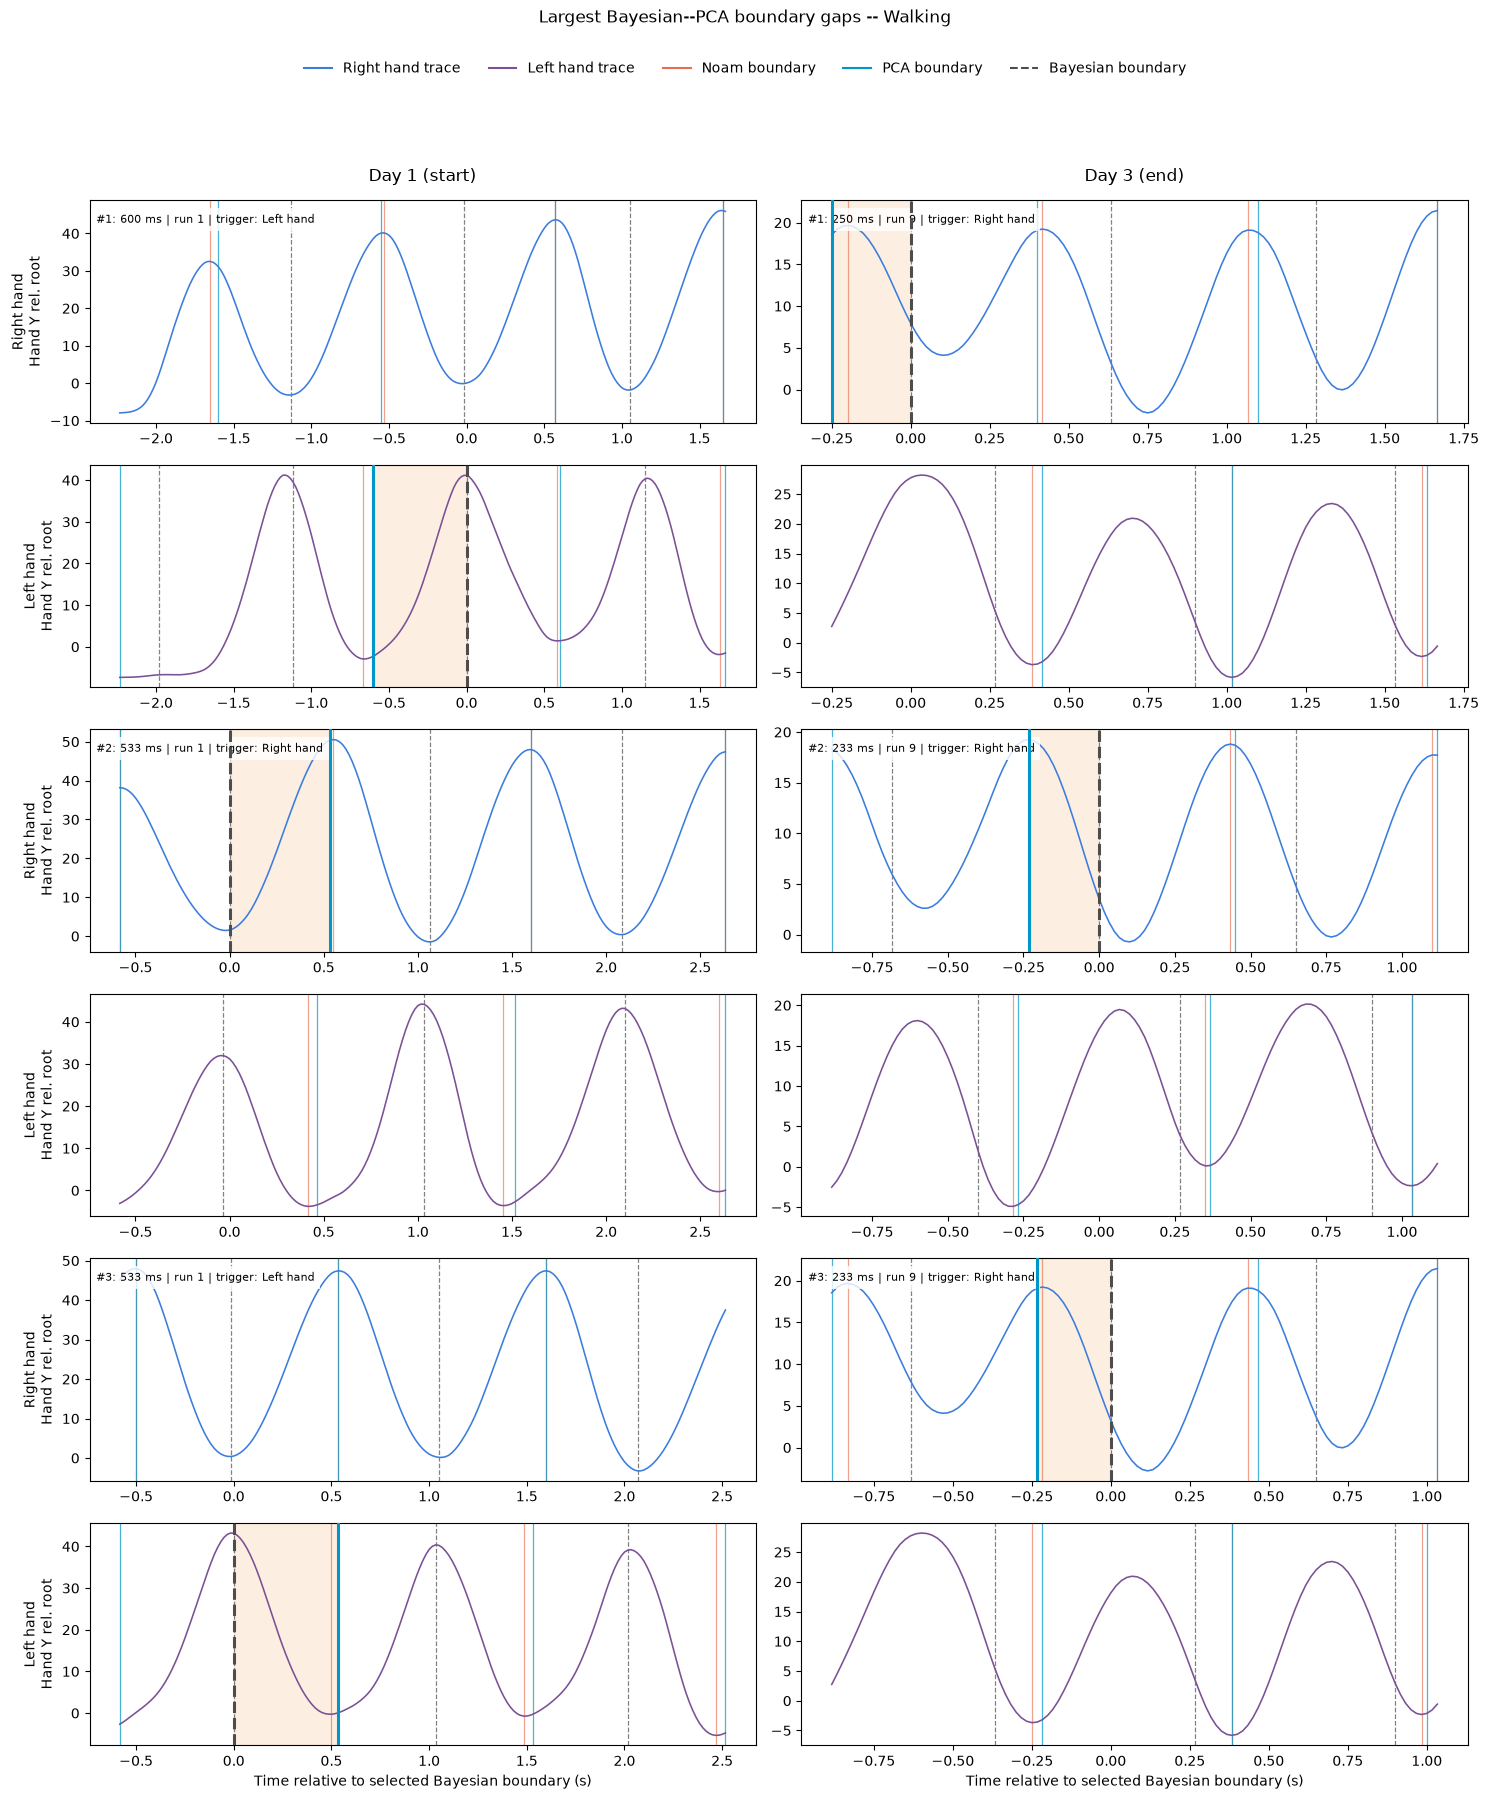

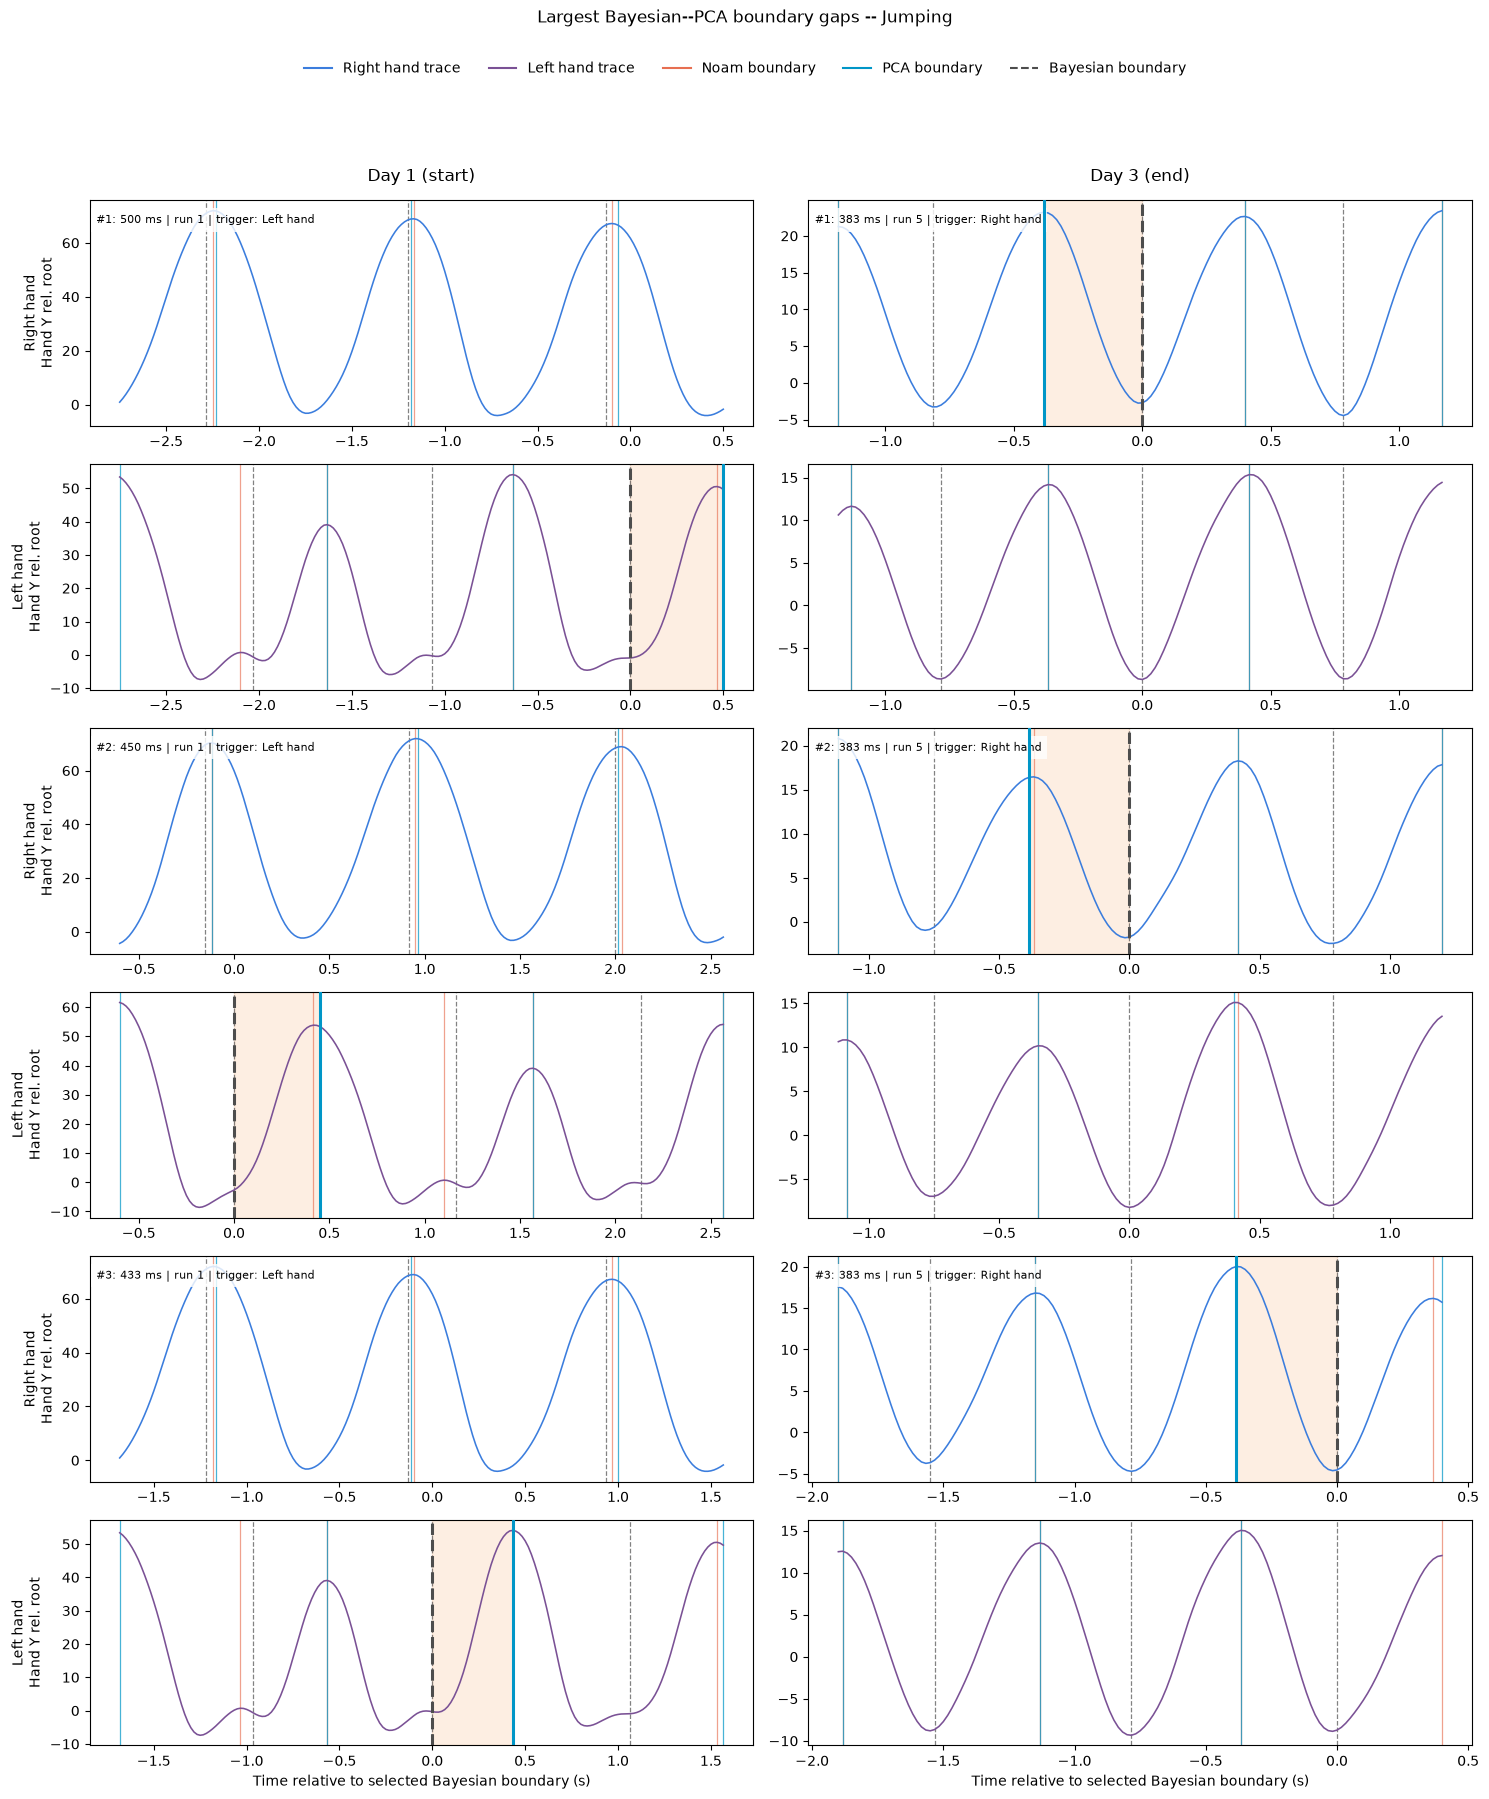

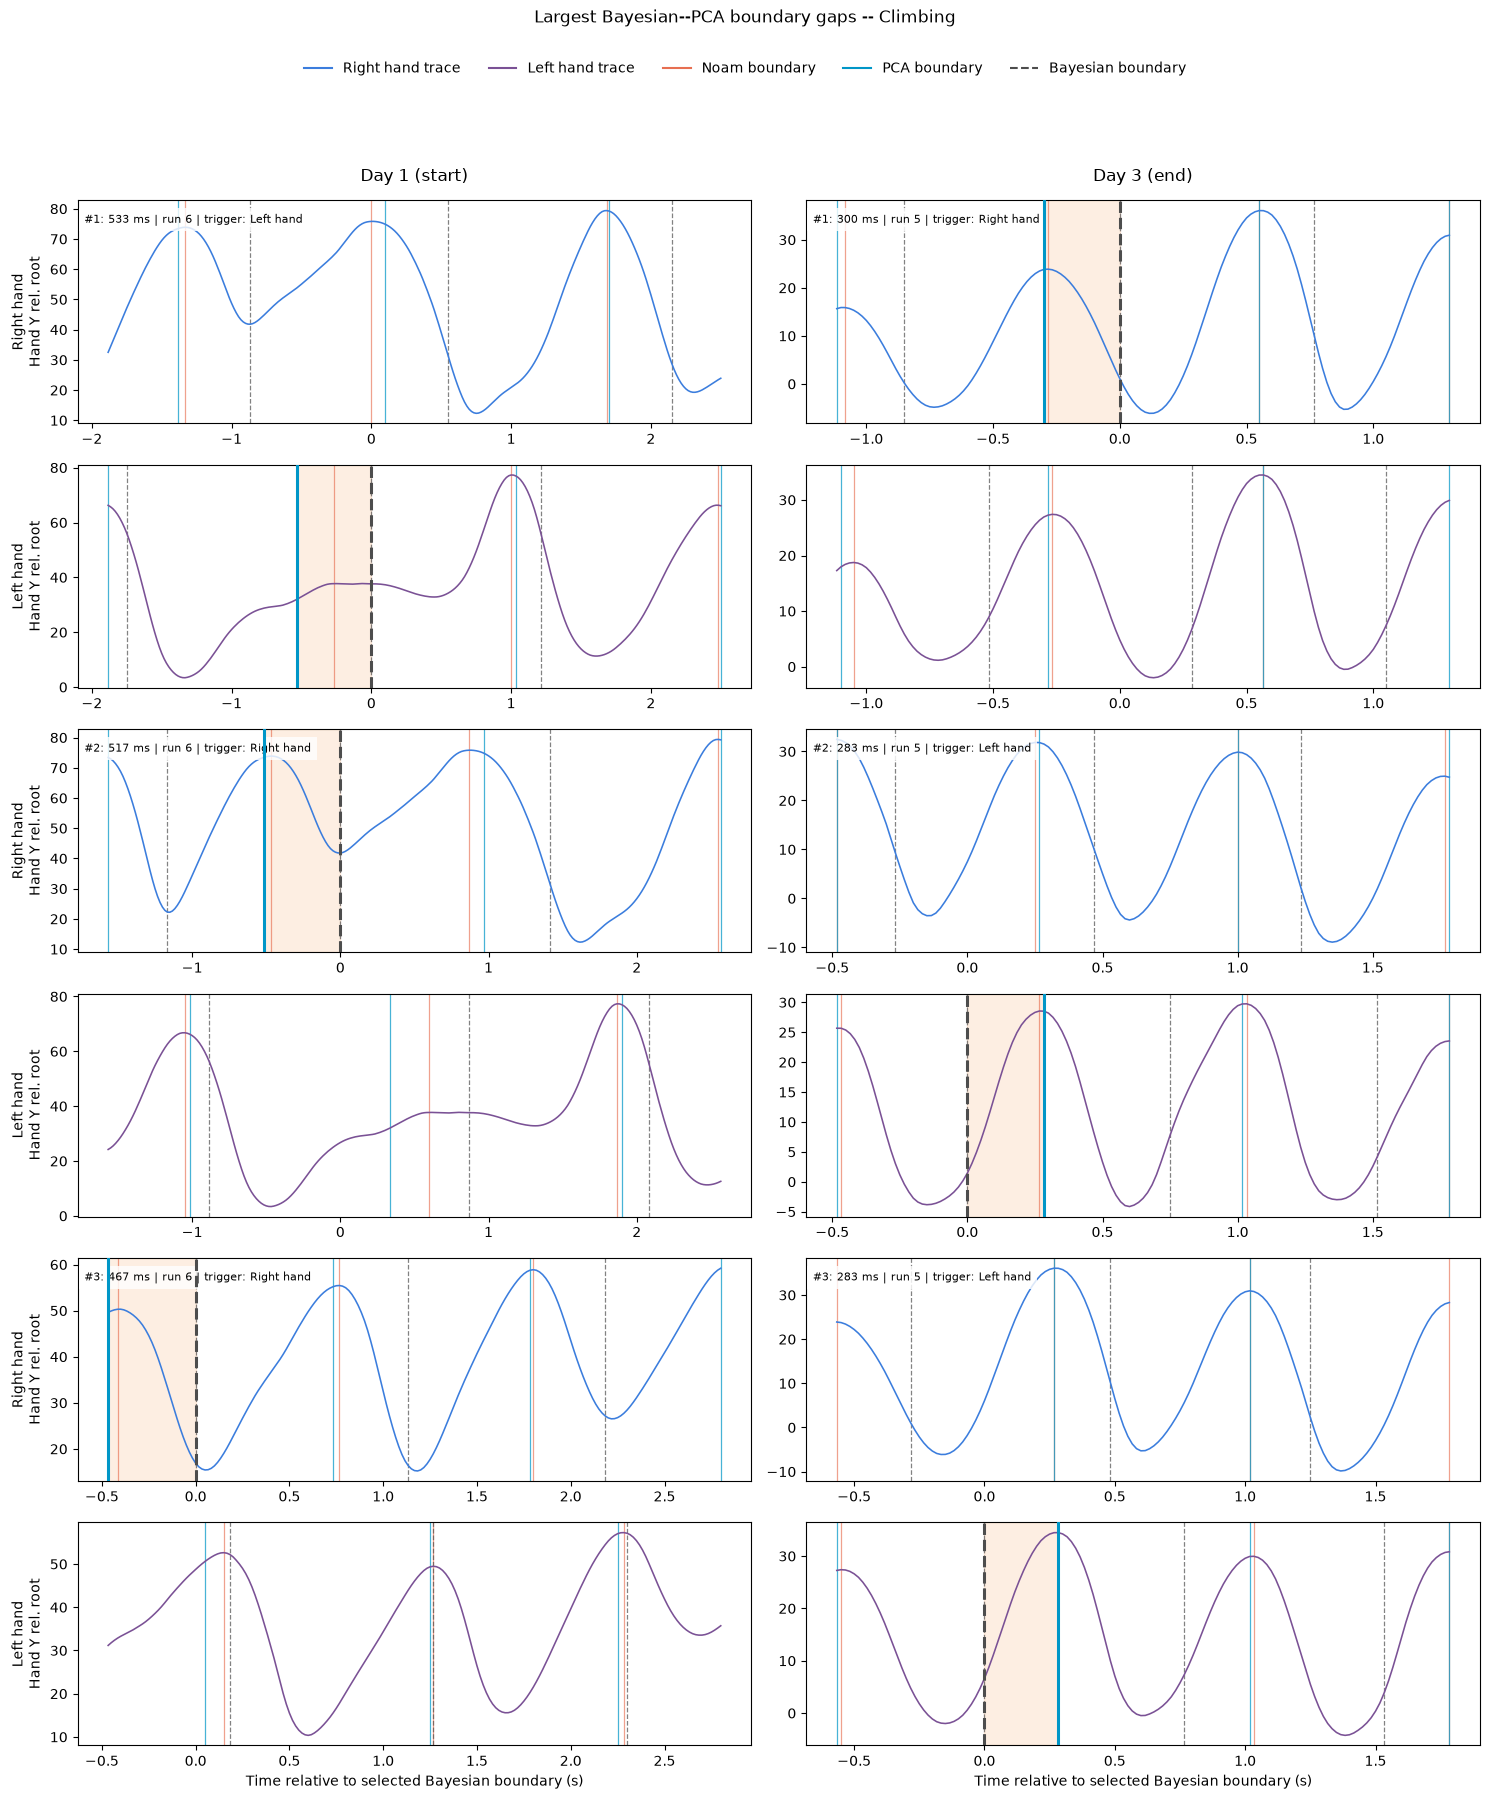

In [5]:
def three_cycle_window(events, center_idx, n_cycles=3):
    """Return n complete PCA cycles with the selected boundary in the middle context."""
    events = np.asarray(events, dtype=int)
    if len(events) < n_cycles + 1:
        return None
    center_pos = int(np.argmin(np.abs(events - center_idx)))
    start_pos = min(max(center_pos - 1, 0), len(events) - (n_cycles + 1))
    return int(events[start_pos]), int(events[start_pos + n_cycles])


worst_gaps = (boundary_gaps_df.sort_values("gap_sec", ascending=False)
              .groupby(["day", "part", "skill"], group_keys=False).head(3))

for skill in ["walk", "jump", "climb"]:
    fig, axes = plt.subplots(6, 2, figsize=(15, 18), squeeze=False)
    for col_idx, (day, part) in enumerate([(1, "s"), (3, "e")]):
        selected = (worst_gaps[(worst_gaps.skill == skill)
                               & (worst_gaps.day == day)
                               & (worst_gaps.part == part)]
                    .sort_values("gap_sec", ascending=False).reset_index(drop=True))
        axes[0, col_idx].set_title(f"Day {day} ({P.PART_LABELS[part]})", fontsize=12, pad=14)

        for rank in range(3):
            if rank >= len(selected):
                for hand_idx in range(2):
                    axes[2 * rank + hand_idx, col_idx].text(
                        0.5, 0.5, "no discrepancy", ha="center", va="center",
                        transform=axes[2 * rank + hand_idx, col_idx].transAxes)
                continue

            discrepancy = selected.iloc[rank]
            trigger_key = ("002", discrepancy.day, discrepancy.part, discrepancy.skill,
                           discrepancy.source_file, discrepancy.run_id, discrepancy.hand)
            trigger_phase = PCA_CACHE[trigger_key]["samples"]["phase"].to_numpy(dtype=float)
            trigger_pca = phase_detection_indices(trigger_phase,
                                                  phase_reference(skill, discrepancy.hand))
            window = three_cycle_window(trigger_pca, discrepancy.pca_event_idx)
            if window is None:
                continue
            start_idx, stop_idx = window
            center_idx = int(discrepancy.bayes_event_idx)

            for hand_idx, hand in enumerate(["r_hand", "l_hand"]):
                ax = axes[2 * rank + hand_idx, col_idx]
                pca_key = ("002", discrepancy.day, discrepancy.part, discrepancy.skill,
                           discrepancy.source_file, discrepancy.run_id, hand)
                bayes_key = ("002", discrepancy.day, discrepancy.part, discrepancy.skill, hand)
                if pca_key not in PCA_CACHE or bayes_key not in BAYES_CACHE:
                    ax.text(0.5, 0.5, "hand not cached", ha="center", va="center", transform=ax.transAxes)
                    continue

                raw = raw_signal_for_run("002", discrepancy.day, discrepancy.part,
                                         discrepancy.skill, discrepancy.run_id, hand)
                phase = PCA_CACHE[pca_key]["samples"]["phase"].to_numpy(dtype=float)
                pca_events = phase_detection_indices(phase, phase_reference(skill, hand))
                _, noam_events = noam_detection_indices(raw, skill, hand, CYCLE_PARAMS)
                bayes_events = bayesian_boundary_indices(BAYES_CACHE[bayes_key]["cycles"])
                local_time = (np.arange(start_idx, stop_idx + 1) - center_idx) / FS_HZ
                ax.plot(local_time, raw[start_idx:stop_idx + 1],
                        color=TRACE_HAND_COLORS[hand], lw=1.15, zorder=3)

                for event_idx in noam_events[(noam_events >= start_idx) & (noam_events <= stop_idx)]:
                    ax.axvline((event_idx - center_idx) / FS_HZ, color=METHOD_COLORS["Noam"],
                               lw=0.9, alpha=0.65, zorder=1)
                for event_idx in pca_events[(pca_events >= start_idx) & (pca_events <= stop_idx)]:
                    ax.axvline((event_idx - center_idx) / FS_HZ, color=METHOD_COLORS["PCA"],
                               lw=0.9, alpha=0.72, zorder=2)
                for event_idx in bayes_events[(bayes_events >= start_idx) & (bayes_events <= stop_idx)]:
                    ax.axvline((event_idx - center_idx) / FS_HZ, color=METHOD_COLORS["Bayesian"],
                               lw=0.9, alpha=0.7, linestyle="--", zorder=2)

                if hand == discrepancy.hand:
                    selected_pca_x = (int(discrepancy.pca_event_idx) - center_idx) / FS_HZ
                    ax.axvspan(min(0, selected_pca_x), max(0, selected_pca_x),
                               color="#f4a261", alpha=0.18, zorder=0)
                    ax.axvline(0, color=METHOD_COLORS["Bayesian"], lw=2.2, linestyle="--", zorder=4)
                    ax.axvline(selected_pca_x, color=METHOD_COLORS["PCA"], lw=2.2, zorder=4)

                if col_idx == 0:
                    ax.set_ylabel(f"{P.HAND_LABELS[hand]}\nHand Y rel. root")
                if hand_idx == 0:
                    ax.text(0.01, 0.94,
                            f"#{rank + 1}: {discrepancy.gap_sec * 1000:.0f} ms | "
                            f"run {discrepancy.run_id} | trigger: {P.HAND_LABELS[discrepancy.hand]}",
                            transform=ax.transAxes, ha="left", va="top", fontsize=8,
                            bbox=dict(facecolor="white", alpha=0.82, edgecolor="none"))

    for ax in axes[-1, :]:
        ax.set_xlabel("Time relative to selected Bayesian boundary (s)")
    fig.legend(handles=[
        Line2D([0], [0], color=TRACE_HAND_COLORS["r_hand"], lw=1.5, label="Right hand trace"),
        Line2D([0], [0], color=TRACE_HAND_COLORS["l_hand"], lw=1.5, label="Left hand trace"),
        Line2D([0], [0], color=METHOD_COLORS["Noam"], lw=1.5, label="Noam boundary"),
        Line2D([0], [0], color=METHOD_COLORS["PCA"], lw=1.5, label="PCA boundary"),
        Line2D([0], [0], color=METHOD_COLORS["Bayesian"], lw=1.5, ls="--", label="Bayesian boundary"),
    ], loc="upper center", ncol=5, frameon=False, bbox_to_anchor=(0.5, 0.975))
    fig.suptitle(f"Largest Bayesian--PCA boundary gaps -- {P.SKILL_LABELS[skill]}", y=0.997)
    fig.tight_layout(rect=(0, 0, 1, 0.935))
    P.save_figure(fig, f"stage5_{skill}_largest_bayesian_pca_boundary_gaps")
    plt.show()

## PCA vs Bayesian: fitted geometric comparison

Unlike the observed-cycle section, this section intentionally compares fitted
geometric quantities. Noam's method has no 3-D plane concept, so it is
PCA-vs-Bayesian only.

In [6]:
geom_rows = []
for _, prow in primary_rows.iterrows():
    day, part, skill, run_id, source_file = prow.day, prow.part, prow.skill, prow.movement_run_id, prow.source_file
    for hand in ["r_hand", "l_hand"]:
        pca_key = ("002", day, part, skill, source_file, run_id, hand)
        bayes_key = ("002", day, part, skill, hand)
        if pca_key not in PCA_CACHE or bayes_key not in BAYES_CACHE:
            continue
        pca_cycles = PCA_CACHE[pca_key]["cycles"]
        bayes_cycles = BAYES_CACHE[bayes_key]["cycles"]
        if pca_cycles.empty or bayes_cycles.empty:
            continue
        geom_rows.append({
            "day": day, "part": part, "skill": skill, "hand": hand,
            "radius_mean_pca": round(float(pca_cycles["radius_mean"].median()), 3),
            "radius_mean_bayes": round(float(bayes_cycles["radius_mean"].median()), 3),
            "perp_sd_pca": round(float(pca_cycles["perp_sd"].median()), 3),
            "perp_sd_bayes": round(float(bayes_cycles["perp_sd"].median()), 3),
        })
geom_df = pd.DataFrame(geom_rows)
geom_df

,day,part,skill,hand,radius_mean_pca,radius_mean_bayes,perp_sd_pca,perp_sd_bayes
0,1,s,climb,r_hand,15.646,11.422,1.283,0.316
1,1,s,climb,l_hand,12.771,10.267,1.325,0.408
2,1,s,jump,r_hand,25.634,21.336,1.530,0.202
3,1,s,jump,l_hand,25.548,21.903,3.070,0.531
4,1,s,walk,r_hand,16.676,13.681,1.033,0.286
5,1,s,walk,l_hand,18.709,16.485,1.602,0.284
6,3,e,climb,r_hand,15.177,13.405,1.392,0.154
7,3,e,climb,l_hand,13.343,12.026,1.399,0.113
8,3,e,jump,r_hand,11.770,11.764,0.333,0.123
9,3,e,jump,l_hand,12.955,12.439,0.796,0.145


## Conclusions

**Observed-cycle comparison:** the waveform plot now compares like with like:
the same raw signal is segmented by Noam, PCA, or Bayesian boundaries. It no
longer mixes a smoothed Noam cycle with reconstructed PCA and posterior-mean
Bayesian trajectories.

**Phase origin:** the boundary-position plot provides the evidence for (or
against) a shared phase offset. Noam detections cluster near PCA phase zero,
as expected from the explicit anchoring. Bayesian boundary positions differ
substantially between condition-hand combinations rather than forming one
common horizontal band. The detailed three-cycle views show the largest gaps
on the underlying signal and include Noam as an independent landmark.

**Cycle counts and durations:** all methods identify broadly similar numbers
and durations of cycles, even where their selected phase-zero locations differ.
These are separate properties: two methods can agree on period while cutting
that period at different points on the waveform.

**Fitted geometry:** Bayesian radii and perpendicular deviations remain smaller
than their PCA counterparts. That comparison concerns fitted latent geometry
and regularization; it should not be inferred from the observed-cycle plot.